# Checkpoint TTT Evaluation

This notebook loads a checkpoint (humanoidmaze baseline 400k steps seed 0), prepares train and test batches exactly like meta_main, and performs 200 updates while logging and plotting train/test losses.


In [1]:
%load_ext autoreload
%autoreload 2

# srun --time=4:0:0 --mem-per-cpu=32G --gpus=1 --pty bash -l
# source scripts/start_jupyter_for_vscode.sh
# ssh -L 8888:localhost:8888 eu-lo-g3-022

In [2]:
import sys
import yaml
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

sys.path.append("..")

import gymnasium as gym
import jax
from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset
from utils.env_utils import make_env_and_datasets
from utils.flax_utils import restore_agent
from utils.config import GCTTTConfig, load_config
from utils.data_selection import get_batch_filters, fetch_meta_batch, sample_start_goal_pairs
from agents.gcagent import MetaGCAgent
import tqdm


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 597, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax_plugins/xla_

In [17]:
# Configuration
CHECKPOINT_PATH = "/cluster/home/anmari/gc_ttt/exp/humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003/seed0"  # Update this path
CHECKPOINT_EPOCH = 400000  # 400k steps
SEED = 0

# You may need to load a config file to get the proper agent config
# For now, we'll try to infer from checkpoint or use defaults
CONFIG_FILE = os.path.dirname(CHECKPOINT_PATH) + "/config.yaml" # Set this if you have a config file
cfg = load_config(CONFIG_FILE)

# Override inner_lr
original_inner_lr = cfg.agent.get("inner_lr")
# cfg.agent["alpha"] = 0.1
inner_lr_to_use = 3e-04 # original_inner_lr
cfg.agent["actor_loss"] = "ddpgbc"
cfg.finetune.actor_loss = "ddpgbc"
cfg.finetune.recursive_selected_num_points = 10
cfg.finetune.min_steps = 10
cfg.finetune.latest_starting_state = False
cfg.finetune.start_from_first = False
cfg.agent["inner_lr"] = inner_lr_to_use
cfg.finetune.inner_lr = inner_lr_to_use

In [18]:
# Set up environment and dataset (exactly like meta_main)
config_agent = cfg.agent
env, train_dataset, val_dataset = make_env_and_datasets(
    cfg.env_name, cfg.data_ratio, frame_stack=config_agent["frame_stack"]
)
env.reset(seed=cfg.seed)
env.action_space.seed(cfg.seed)

dataset_class = {
    "GCDataset": GCDataset,
    "HGCDataset": HGCDataset,
}[config_agent["dataset_class"]]
train_dataset = dataset_class(Dataset.create(**train_dataset), config_agent)
if val_dataset is not None:
    val_dataset = dataset_class(Dataset.create(**val_dataset), config_agent)

print(f"Environment: {cfg.env_name}")
print(f"Dataset class: {config_agent['dataset_class']}")


Environment: humanoidmaze-medium-stitch-v0
Dataset class: GCDataset


In [19]:
# Initialize agent (exactly like meta_main)
random.seed(cfg.seed)
np.random.seed(cfg.seed)

example_batch = train_dataset.sample(1)
if config_agent["discrete"]:
    # Fill with the maximum action to let the agent know the action space size.
    example_batch["actions"] = np.full_like(
        example_batch["actions"], env.action_space.n - 1
    )

agent_class = agents[config_agent["agent_name"]]
agent: MetaGCAgent
agent = agent_class.create(
    cfg.seed,
    example_batch["observations"],
    example_batch["actions"],
    config_agent,
    cfg.train_steps,
)

print(f"Agent created: {config_agent['agent_name']}")

# Restore agent from checkpoint
print(f"Restoring agent from {CHECKPOINT_PATH} at epoch {CHECKPOINT_EPOCH}")
agent: MetaGCAgent = restore_agent(agent, CHECKPOINT_PATH, CHECKPOINT_EPOCH)
print("Agent restored successfully!")

Agent created: gciql
Restoring agent from /cluster/home/anmari/gc_ttt/exp/humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003/seed0 at epoch 400000
Restoring learning rate multiplier: 1.0
Restored from /cluster/home/anmari/gc_ttt/exp/humanoidmaze_stitch/iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003/seed0/params_400000.pkl
Agent restored successfully!


In [94]:
# GC-TTT-with-critic: Fine-tuning and rollout with replanning loop
# This implements the protocol from utils/evaluation.py gc_ttt_critic function

from utils.evaluation import supply_rng, clone_agent, flatten
from collections import defaultdict

actor_only = True

# Simulate evaluation protocol: Sample starting state and goal from environment
# This mimics the protocol used in utils/evaluation.py evaluate() function

task_id = 4  # Task ID to evaluate (can be changed)
eval_seed = 1  # Seed for evaluation episode

# Reset environment to get starting state and goal (like in evaluation.py)
start_state, info = env.reset(
    options=dict(task_id=task_id, render_goal=False),
    seed=eval_seed
)

# Extract goal from info (like in evaluation.py line 569)
goal = info.get("goal")
goal_frame = info.get("goal_rendered")

print(f"Evaluation Protocol - Sampled State and Goal:")
print(f"  Task ID: {task_id}")
print(f"  Evaluation seed: {eval_seed}")
print(f"  Start state shape: {start_state.shape}")
print(f"  Goal shape: {goal.shape if goal is not None else 'None'}")
print(f"  Start state (first 5 dims): {start_state[:5] if len(start_state) >= 5 else start_state}")
print(f"  Goal (first 5 dims): {goal[:5] if goal is not None and len(goal) >= 5 else goal}")

# Store for later use
eval_start_state = start_state
eval_goal = goal

# Helper function from evaluation.py
def add_to(dict_of_lists, single_dict):
    """Append values to the corresponding lists in the dictionary."""
    for k, v in single_dict.items():
        dict_of_lists[k].append(v)

# Configuration for GC-TTT
finetune_config = cfg.finetune
num_ttt_steps = 100 # cfg.finetune.get("num_steps", 10)  # Number of fine-tuning steps per replanning phase
replan_horizon = 100 # cfg.finetune.get("replan_horizon", 100)  # Steps to execute before replanning
max_episode_steps = 3000  # Maximum episode length

# Use the sampled state and goal from evaluation protocol
observation = eval_start_state.copy()
goal = eval_goal.copy()

# Prepare state-to-goal distance (for filtering) - computed once at the beginning
print("Preparing state-to-goal distance...")
state_to_goal_dist, values = train_dataset.prepare_values(agent, goal, finetune_config, return_values=True)


# Storage for trajectory and statistics
traj = defaultdict(list)
finetune_stats = defaultdict(list)
aggregated_filters = []

# Initialize
done = False
step = 0
agent_ft = None
observations_list = [observation.copy()]
replan_phases = []  # Track which replanning phase each step belongs to

# Initial actor function (will be updated after each fine-tuning)
actor_fn = supply_rng(
    agent.sample_actions,
    rng=jax.random.PRNGKey(np.random.randint(0, 2**32)),
)

print(f"\nStarting GC-TTT with replanning loop:")
print(f"  - Fine-tuning steps per phase: {num_ttt_steps}")
print(f"  - Replan horizon: {replan_horizon}")
print(f"  - Max episode steps: {max_episode_steps}\n")

# Replanning loop: repeatedly fine-tune and execute a short horizon
replan_phase = 0
while not done:
    replan_phase += 1
    print(f"=== Replanning Phase {replan_phase} ===")

    # Clone agent fresh for each replanning phase
    agent_ft = clone_agent(agent)
    finetune_stats = defaultdict(list)

    # Handle cube_env config if needed
    if finetune_config.get("cube_env", False):
        num_cubes = env._num_cubes if hasattr(env, "_num_cubes") else 1
        finetune_config["num_cubes"] = num_cubes
        finetune_config["proprio_dim"] = env.observation_space.shape[0] - num_cubes * 9

    # Filtering the dataset for active test-time fine-tuning
    print("Observation: ", observation[:2])
    _filter, max_len = train_dataset.prepare_active_sample(
        agent,  # Use original agent for filtering
        observation,
        goal,
        cfg.env_name,
        finetune_config,
        state_to_goal_dist=state_to_goal_dist
    )

    aggregated_filters.append(_filter)
    print(f"Filter has {_filter.sum()} valid samples")

    # Fine-tuning phase
    if _filter.sum() > 0:
        print(f"Fine-tuning for {num_ttt_steps} steps...")
        for i in range(num_ttt_steps):
            # Sample batch from filtered dataset
            batch = train_dataset.active_sample(
                finetune_config.get("batch_size", 1024),
                _filter,
                goal,
                finetune_config.get("ratio", 1.0),
                finetune_config.get("fix_actor_goal", 1.0),
                hierarchical=(agent.config.get('agent_name') == 'saw')
            )

            # Update agent (note: reset_inner_opt=False as in original)
            agent_ft, update_info = agent_ft.update(
                batch,
                finetuning=True,
                reset_inner_opt=False,  # Match original code
                actor_only=actor_only
            )

            # Flatten and store stats
            add_to(finetune_stats, flatten(update_info))

            if i == 0 or (i + 1) % 5 == 0:
                loss = update_info.get("total_loss", update_info.get("train/total_loss", 0.0))
                print(f"  Step {i+1}/{num_ttt_steps}: Loss = {loss:.6f}")
    else:
        print("Warning: Empty filter, skipping fine-tuning")

    # Create actor function from fine-tuned agent
    actor_fn = supply_rng(
        agent_ft.sample_actions,
        rng=jax.random.PRNGKey(np.random.randint(0, 2**32)),
    )

    # Execute the policy for a fixed short horizon before replanning
    print(f"Executing policy for up to {replan_horizon} steps...")
    for _step in range(replan_horizon):
        if done:
            break

        # Check if reset_after_horizon is set and we've exceeded max_len
        if _step > max_len and finetune_config.get("reset_after_horizon", False):
            agent_ft = clone_agent(agent)
            actor_fn = supply_rng(
                agent_ft.sample_actions,
                rng=jax.random.PRNGKey(np.random.randint(0, 2**32)),
            )

        # Sample action
        action = actor_fn(
            observations=observation,
            goals=goal,
            temperature=cfg.eval_temperature if hasattr(cfg, 'eval_temperature') else 1.0
        )
        action = np.array(action)

        if not cfg.agent.get("discrete"):
            if hasattr(cfg, 'eval_gaussian') and cfg.eval_gaussian is not None:
                action = np.random.normal(action, cfg.eval_gaussian)
            action = np.clip(action, -1, 1)

        # Step environment
        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1
        done = done or step >= max_episode_steps

                # Store transition
        transition = dict(
            observation=observation.copy(),
            next_observation=next_observation.copy(),
            action=action.copy(),
            reward=reward,
            done=done,
            info=info,
        )
        add_to(traj, transition)
        observations_list.append(next_observation.copy())
        observation = next_observation  # Update state for the next replan phase

        # Track which replanning phase this step belongs to
        replan_phases.append(replan_phase)

        if done:
            print(f"Episode terminated at step {step}")
            break

    print(f"Phase {replan_phase} complete: {step} total steps, Done: {done}\n")

print(f"\n=== GC-TTT Complete ===")
print(f"Total steps: {step}")
print(f"Success: {info.get('success', False) if info else False}")
print(f"Number of replanning phases: {replan_phase}")

# Store trajectory for visualization
rollout_trajectory = {
    'observations': np.array(observations_list),
    'actions': np.array(traj['action']),
    'rewards': np.array(traj['reward']),
    'goal': goal,
    'num_steps': step,
    'replan_phases': np.array(replan_phases),
    'aggregated_filters': aggregated_filters,
    'precomputed_values': values  # Store precomputed values from state_to_goal_dist
}

Evaluation Protocol - Sampled State and Goal:
  Task ID: 4
  Evaluation seed: 1
  Start state shape: (69,)
  Goal shape: (69,)
  Start state (first 5 dims): [15.97035182 20.26547546  0.19397725  0.11434921  0.13805958]
  Goal (first 5 dims): [ 0.63645344 20.36605199 -0.40991781  0.0542155  -0.28282733]
Preparing state-to-goal distance...

Starting GC-TTT with replanning loop:
  - Fine-tuning steps per phase: 100
  - Replan horizon: 100
  - Max episode steps: 3000

=== Replanning Phase 1 ===
Observation:  [15.97035182 20.26547546]
Filter has 857.0 valid samples
Fine-tuning for 100 steps...
  Step 1/100: Loss = 19.937328
  Step 5/100: Loss = 19.805134
  Step 10/100: Loss = 19.702682
  Step 15/100: Loss = 19.642574
  Step 20/100: Loss = 19.591482
  Step 25/100: Loss = 19.561481
  Step 30/100: Loss = 19.534616
  Step 35/100: Loss = 19.505623
  Step 40/100: Loss = 19.490788
  Step 45/100: Loss = 19.469048
  Step 50/100: Loss = 19.451042
  Step 55/100: Loss = 19.441257
  Step 60/100: Loss = 

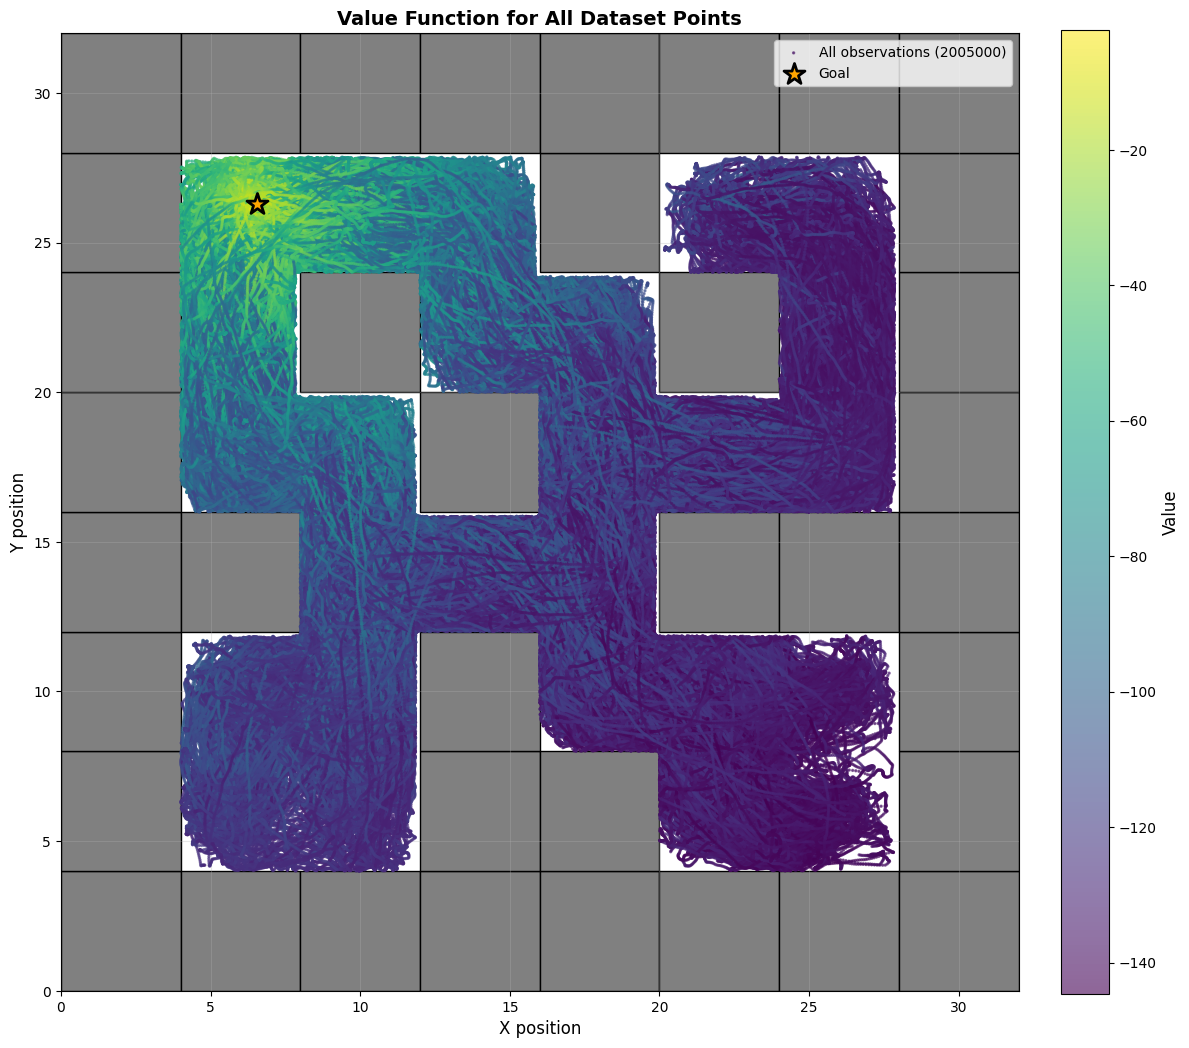

Value statistics:
  Min: -144.6259
  Max: -2.3068
  Mean: -113.9691
  Std: 22.6884


In [95]:
# Plot values for all points in the dataset
from utils.plotting import draw_maze, get_agent_position

# Get maze parameters
maze_map = env.unwrapped.maze_map
maze_unit = getattr(env.unwrapped, '_maze_unit', 4.0)
original_offset_x = getattr(env.unwrapped, '_offset_x', 4.0)
original_offset_y = getattr(env.unwrapped, '_offset_y', 4.0)

# Compute offset transformation
all_obs = train_dataset.dataset['observations']
all_obs_xy = all_obs[:, :2]
x_max, x_min = np.max(all_obs_xy[:, 0]), np.min(all_obs_xy[:, 0])
y_max, y_min = np.max(all_obs_xy[:, 1]), np.min(all_obs_xy[:, 1])

# Recompute offsets
offset_x = (0 - x_min/maze_unit) + 1
offset_y = (0 - y_min/maze_unit) + 1

# Get all values (already computed in Cell 7)
# Check both local and global scope for Jupyter notebook compatibility
try:
    all_values = np.array(values) if values is not None else None
except NameError:
    all_values = None

if all_values is not None:
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 12))

    # Draw maze structure
    draw_maze(ax, maze_map, maze_unit, original_offset_x, original_offset_y)

    # Plot all observations colored by value
    obs_xy_transformed = all_obs_xy.copy()
    obs_xy_transformed[:, 0] = obs_xy_transformed[:, 0] + offset_x * maze_unit
    obs_xy_transformed[:, 1] = obs_xy_transformed[:, 1] + offset_y * maze_unit

    scatter = ax.scatter(obs_xy_transformed[:, 0], obs_xy_transformed[:, 1],
                        c=all_values, cmap='viridis', alpha=0.6, s=2,
                        label=f'All observations ({len(all_obs_xy)})', zorder=2)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Value', fontsize=12)

    # Plot goal if available
    if 'goal' in locals() and goal is not None:
        goal_xy = get_agent_position(goal, cfg.env_name)
        goal_xy_transformed = goal_xy.copy()
        goal_xy_transformed[0] = goal_xy[0] + offset_x * maze_unit
        goal_xy_transformed[1] = goal_xy[1] + offset_y * maze_unit
        ax.scatter(goal_xy_transformed[0], goal_xy_transformed[1], c='orange', s=250, marker='*',
                  edgecolors='black', linewidths=2, label='Goal', zorder=7)

    # Set axis limits
    ax.set_xlim(0, 32)
    ax.set_ylim(0, 32)

    ax.set_xlabel('X position', fontsize=12)
    ax.set_ylabel('Y position', fontsize=12)
    ax.set_title('Value Function for All Dataset Points', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"Value statistics:")
    print(f"  Min: {all_values.min():.4f}")
    print(f"  Max: {all_values.max():.4f}")
    print(f"  Mean: {all_values.mean():.4f}")
    print(f"  Std: {all_values.std():.4f}")
else:
    print("Error: Values not found. Please run Cell 7 first to compute values.")


In [96]:
# Interactive visualization with maze structure and filtered samples
# Shows trajectory at specific steps with filtered samples for the current fine-tuning phase
from ipywidgets import IntSlider, Output, VBox
from IPython.display import display, clear_output
from utils.plotting import draw_maze, get_agent_position

def plot_eval_episode(rollout_trajectory):
    # Get maze parameters
    maze_map = env.unwrapped.maze_map
    maze_unit = getattr(env.unwrapped, '_maze_unit', 4.0)
    original_offset_x = getattr(env.unwrapped, '_offset_x', 4.0)
    original_offset_y = getattr(env.unwrapped, '_offset_y', 4.0)

    # Compute offset transformation like in plot_maze_and_samples
    # Sample some observations to compute min/max for offset calculation
    all_obs_sample = train_dataset.dataset['observations'][np.random.choice(len(train_dataset.dataset['observations']), 5000)]
    all_obs_xy = all_obs_sample[:, :2]
    x_max, x_min = np.max(all_obs_xy[:, 0]), np.min(all_obs_xy[:, 0])
    y_max, y_min = np.max(all_obs_xy[:, 1]), np.min(all_obs_xy[:, 1])

    # Recompute offsets like in plot_maze_and_samples (line 70-71)
    offset_x = (0 - x_min/maze_unit) + 1
    offset_y = (0 - y_min/maze_unit) + 1

    # Get aggregated filters and replan phases
    aggregated_filters = rollout_trajectory['aggregated_filters']
    replan_phases = rollout_trajectory.get('replan_phases', np.zeros(len(rollout_trajectory['observations'])))
    goal = rollout_trajectory['goal']

    # Use precomputed values from state_to_goal_dist (already computed in GC-TTT cell)
    values = rollout_trajectory.get('precomputed_values', None)

    # Sample observations for visualization
    all_obs_xy_full = train_dataset.dataset['observations'][:, :2]
    sample_size = min(5000, len(all_obs_xy_full))
    sample_idx = np.random.choice(len(all_obs_xy_full), sample_size, replace=False)
    sampled_obs_xy = all_obs_xy_full[sample_idx]

    # Get precomputed values for sampled observations
    if values is not None:
        precomputed_values = np.array(values)[sample_idx]
        values_available = True
    else:
        precomputed_values = None
        values_available = False

    # Define frame steps to show (20, 40, 60, 80, 100, ...)
    frame_interval = 10
    max_step = len(rollout_trajectory['observations']) - 1
    available_steps = [i for i in range(0, max_step + 1, frame_interval)]
    if available_steps[-1] != max_step:
        available_steps.append(max_step)  # Always include the last step

    # Create output widget
    output = Output()

    # Create slider with only available steps
    slider = IntSlider(
        value=0,
        min=0,
        max=len(available_steps) - 1,
        step=1,
        description='Frame:',
        style={'description_width': 'initial'},
        layout={'width': '500px'}
    )

    def on_slider_change(change):
        frame_idx = change['new']
        step_idx = available_steps[frame_idx]

        with output:
            clear_output(wait=True)

            obs = rollout_trajectory['observations']
            goal = rollout_trajectory['goal']
            num_steps = rollout_trajectory['num_steps']

            # Get current replanning phase and its filter
            current_phase = int(replan_phases[step_idx]) if step_idx < len(replan_phases) else 0
            current_filter = aggregated_filters[current_phase - 1] if current_phase > 0 and len(aggregated_filters) >= current_phase else None

            # Create smaller figure
            fig, ax = plt.subplots(figsize=(7, 7))

                        # Draw maze structure (using original offsets for drawing)
            draw_maze(ax, maze_map, maze_unit, original_offset_x, original_offset_y)

            # Plot all observations in background (like plot_maze_and_samples)
            all_obs_sample = train_dataset.dataset['observations'][np.random.choice(len(train_dataset.dataset['observations']), 5000)]
            all_obs_xy = all_obs_sample[:, :2]
            ax.scatter(all_obs_xy[:, 0] + offset_x * maze_unit,
                    all_obs_xy[:, 1] + offset_y * maze_unit,
                    c='lightgray', alpha=0.4, s=5, label='All observations (sample)', zorder=1)

            # Plot filtered samples for current phase (like plot_maze_and_samples)
            if current_filter is not None and current_filter.sum() > 0:
                filtered_obs = train_dataset.dataset['observations'][current_filter.astype(bool)]
                filtered_obs_xy = filtered_obs[:, :2] if len(filtered_obs) > 0 else np.zeros((0, 2))
                if len(filtered_obs_xy) > 0:
                    # Show filtered samples colored by value if available, otherwise in blue
                    if values_available and values is not None:
                        filtered_values = np.array(values)[current_filter.astype(bool)]
                        if len(filtered_values) > 0:
                            scatter = ax.scatter(filtered_obs_xy[:, 0] + offset_x * maze_unit,
                                                filtered_obs_xy[:, 1] + offset_y * maze_unit,
                                                c=filtered_values, cmap='viridis', alpha=0.6, s=10,
                                                label=f'Filtered observations ({len(filtered_obs_xy)})', zorder=2)
                            # Add colorbar
                            cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
                            cbar.set_label('Value', fontsize=8)
                        else:
                            ax.scatter(filtered_obs_xy[:, 0] + offset_x * maze_unit,
                                    filtered_obs_xy[:, 1] + offset_y * maze_unit,
                                    c='blue', alpha=0.5, s=10, label=f'Filtered observations ({len(filtered_obs_xy)})', zorder=2)
                    else:
                        ax.scatter(filtered_obs_xy[:, 0] + offset_x * maze_unit,
                                filtered_obs_xy[:, 1] + offset_y * maze_unit,
                                c='blue', alpha=0.5, s=10, label=f'Filtered observations ({len(filtered_obs_xy)})', zorder=2)
            else:
                print("Warning: No observations passed the filter")

            # Extract positions using get_agent_position
            positions = np.array([get_agent_position(obs[i], cfg.env_name) for i in range(len(obs))])
            start_xy = get_agent_position(obs[0], cfg.env_name)
            goal_xy = get_agent_position(goal, cfg.env_name) if goal is not None else None

            # Apply offset transformation to positions
            positions_transformed = positions.copy()
            positions_transformed[:, 0] = positions[:, 0] + offset_x * maze_unit
            positions_transformed[:, 1] = positions[:, 1] + offset_y * maze_unit
            start_xy_transformed = start_xy.copy()
            start_xy_transformed[0] = start_xy[0] + offset_x * maze_unit
            start_xy_transformed[1] = start_xy[1] + offset_y * maze_unit
            if goal_xy is not None:
                goal_xy_transformed = goal_xy.copy()
                goal_xy_transformed[0] = goal_xy[0] + offset_x * maze_unit
                goal_xy_transformed[1] = goal_xy[1] + offset_y * maze_unit
            else:
                goal_xy_transformed = None

            # Plot full trajectory up to current step
            if step_idx > 0:
                ax.plot(positions_transformed[:step_idx+1, 0], positions_transformed[:step_idx+1, 1], 'b-',
                    alpha=0.6, linewidth=2, label='Past trajectory', zorder=4)

            # Plot future trajectory (if available)
            if step_idx < len(positions_transformed) - 1:
                ax.plot(positions_transformed[step_idx:, 0], positions_transformed[step_idx:, 1], 'gray',
                    alpha=0.2, linewidth=1, linestyle='--', label='Future trajectory', zorder=3)

            # Plot current position
            if step_idx < len(positions_transformed):
                current_pos = positions_transformed[step_idx]
                ax.scatter(current_pos[0], current_pos[1], c='red', s=150, marker='o',
                        edgecolors='black', linewidths=2, label='Current position', zorder=7)

            # Plot start position
            ax.scatter(start_xy_transformed[0], start_xy_transformed[1], c='green', s=150, marker='s',
                    edgecolors='black', linewidths=2, label='Start', zorder=7)

            # Plot goal
            if goal_xy_transformed is not None:
                ax.scatter(goal_xy_transformed[0], goal_xy_transformed[1], c='orange', s=250, marker='*',
                        edgecolors='black', linewidths=2, label='Goal', zorder=7)

            # Add arrow showing direction of movement
            if step_idx > 0 and step_idx < len(positions_transformed):
                prev_pos = positions_transformed[step_idx - 1]
                curr_pos = positions_transformed[step_idx]
                dx = curr_pos[0] - prev_pos[0]
                dy = curr_pos[1] - prev_pos[1]
                if np.abs(dx) > 1e-6 or np.abs(dy) > 1e-6:
                    ax.arrow(prev_pos[0], prev_pos[1], dx*0.8, dy*0.8,
                            head_width=0.15, head_length=0.15, fc='blue', ec='blue',
                            alpha=0.7, zorder=6)

            # Set axis limits like in plot_maze_and_samples (0, 32 for 8x8 maze)
            ax.set_xlim(0, 32)
            ax.set_ylim(0, 32)

            ax.set_xlabel('X position', fontsize=10)
            ax.set_ylabel('Y position', fontsize=10)
            ax.set_title(f'Step {step_idx}/{num_steps} - Phase {current_phase}', fontsize=12, fontweight='bold')
            ax.legend(loc='upper right', fontsize=8, ncol=2)
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal', adjustable='box')

            # Add info text
            if step_idx < len(rollout_trajectory['rewards']):
                reward = rollout_trajectory['rewards'][step_idx]
                info_text = f'Step: {step_idx}\nPhase: {current_phase}\nReward: {reward:.3f}'
                if step_idx > 0:
                    cumulative_reward = np.sum(rollout_trajectory['rewards'][:step_idx+1])
                    info_text += f'\nCumulative: {cumulative_reward:.3f}'
                ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            plt.tight_layout()
            plt.show()

    # Connect slider to update function
    slider.observe(on_slider_change, names='value')

    # Display widget with step info
    print(f"Available frames: {available_steps}")
    display(VBox([slider, output]))

    # Show initial plot
    on_slider_change({'new': 0})


plot_eval_episode(rollout_trajectory)

Available frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180, 1190, 1200, 1210, 1220, 1230, 1240, 1250, 1260, 1270, 1280, 1290, 1300, 1310, 1320, 1330, 1340, 1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420, 1430, 1440, 1450, 1460, 1470, 1480, 1490, 1500, 1510, 1520, 1530, 1540, 1550, 1560, 1570, 1580, 1590, 1600, 1610, 1620, 1630, 1640, 1650, 1660, 1670, 1680, 1690, 1700, 1710, 1720, 1730, 1740, 1750, 1760, 1770, 1780, 1790, 1800, 1810, 

Task filter has 894.0 valid samples
Fetching meta batch: filter has 894.0 samples
Test batch size: 128


Task filter has 1972.0 valid samples
Fetching meta batch: filter has 1972.0 samples
Test batch size: 128

==== Repeat 1/10 ====
Maze map shape: (8, 8)
Maze unit: 4.0, Offset: (4, 4)


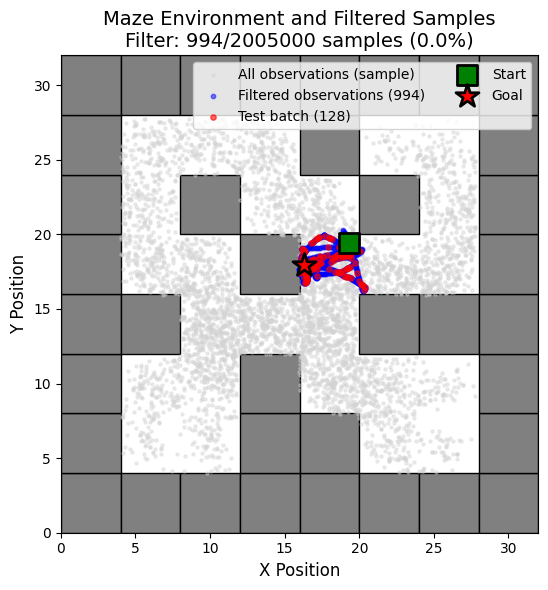

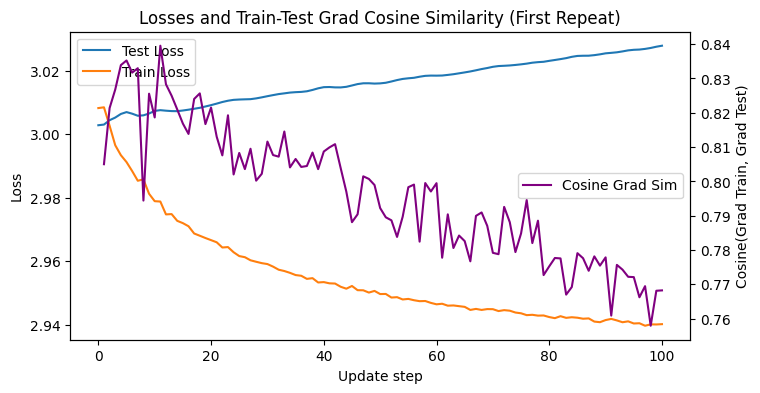

Task filter has 1416.0 valid samples
Fetching meta batch: filter has 1416.0 samples
Test batch size: 128

==== Repeat 2/10 ====
Task filter has 3178.0 valid samples
Fetching meta batch: filter has 3178.0 samples
Test batch size: 128

==== Repeat 3/10 ====
Task filter has 2609.0 valid samples
Fetching meta batch: filter has 2609.0 samples
Test batch size: 128

==== Repeat 4/10 ====
Task filter has 2819.0 valid samples
Fetching meta batch: filter has 2819.0 samples
Test batch size: 128

==== Repeat 5/10 ====
Task filter has 1539.0 valid samples
Fetching meta batch: filter has 1539.0 samples
Test batch size: 128

==== Repeat 6/10 ====
Task filter has 3376.0 valid samples
Fetching meta batch: filter has 3376.0 samples
Test batch size: 128

==== Repeat 7/10 ====
Task filter has 2136.0 valid samples
Fetching meta batch: filter has 2136.0 samples
Test batch size: 128

==== Repeat 8/10 ====
Task filter has 2772.0 valid samples
Fetching meta batch: filter has 2772.0 samples
Test batch size: 128

In [20]:
from utils.evaluation import clone_agent
from utils.plotting import plot_maze_and_samples, get_agent_position, draw_maze

import jax
import jax.numpy as jnp
from functools import partial
import matplotlib.pyplot as plt

actor_only = True # getattr(cfg.finetune, 'actor_only', False)
use_meta_update = True
is_fomaml = False  # Not using FOMAML for this evaluation
NUM_UPDATES = 100
N_REPEAT = 10
# Prepare for updates - get initial task (exactly like meta_main)
is_stitch_dataset = "stitch" in cfg.env_name
train_on_test_goal = False
# For collecting repeat-wise results:
repeat_results = []

# Utility: flatten PyTree to vector (for cosine sim)
def flatten_params(params):
    leaves, _ = jax.tree_util.tree_flatten(params)
    return jnp.concatenate([jnp.ravel(leaf) for leaf in leaves])

# grad fns
def loss_fn_train(params, train_batch, agent, actor_only):
    loss, _ = agent.total_loss(
        train_batch,
        grad_params=params,
        fixed_params=params,
        actor_only=actor_only
    )
    return loss

def loss_fn_test(params, test_batch, agent, actor_only):
    loss, _ = agent.total_loss(
        test_batch,
        grad_params=params,
        fixed_params=params,
        actor_only=actor_only
    )
    return loss

grad_fn_train = jax.grad(loss_fn_train)
grad_fn_test = jax.grad(loss_fn_test)

for repeat in range(N_REPEAT):


    # Sample start and goal pairs
    start_states, goals = sample_start_goal_pairs(
        train_dataset,
        env,
        1,  # meta_batch_size = 1 for single task
        train_on_test_goal,
        is_stitch_dataset=is_stitch_dataset,
        finetune_config=cfg.finetune
    )


    # Get batch filters
    batch_filters_and_max_lens = get_batch_filters(
        train_dataset,
        agent,
        start_states,
        goals,
        cfg,
    )

    task_filter = batch_filters_and_max_lens[0][0]
    print(f"Task filter has {task_filter.sum()} valid samples")
    # Get test batch (exactly like meta_main)
    test_batch, test_batch_idx = fetch_meta_batch(
        train_dataset,
        goals[0],
        agent,
        cfg.finetune,
        batch_filters_and_max_lens[0],
        meta_batch_size=128,  # Same as meta_main
        fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
        verbose=True
    )
    print(f"Test batch size: {test_batch['observations'].shape[0]}")

    print(f"\n==== Repeat {repeat+1}/{N_REPEAT} ====")
    # Re-sample start/goal for each repeat
    start_states, goals = sample_start_goal_pairs(
        train_dataset,
        env,
        1,  # meta_batch_size = 1 for single task
        False, # train_on_test_goal
        is_stitch_dataset="stitch" in cfg.env_name,
        finetune_config=cfg.finetune
    )

    batch_filters_and_max_lens = get_batch_filters(
        train_dataset,
        agent,
        start_states,
        goals,
        cfg,
    )
    task_filter = batch_filters_and_max_lens[0][0]
    test_batch, test_batch_idx = fetch_meta_batch(
        train_dataset,
        goals[0],
        agent,
        cfg.finetune,
        batch_filters_and_max_lens[0],
        meta_batch_size=128,  # Same as meta_main
        fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
        verbose=False
    )

    # Storage for losses and cosine similarities for this repeat
    train_losses = []
    test_losses = []
    update_steps = []
    cosine_sims = []

    # Compute initial test loss
    _, test_info = agent.total_loss(
        test_batch,
        grad_params=agent.network.params,
        fixed_params=agent.network.params,
        actor_only=actor_only
    )
    initial_test_loss = float(test_info.get("total_loss", test_info.get("test/total_loss", 0.0)))
    test_losses.append(initial_test_loss)
    cosine_sims.append(float("nan"))  # Undefined for initial step

    # Compute initial train loss
    train_batch, _ = fetch_meta_batch(
        train_dataset,
        goals[0],
        agent,
        cfg.finetune,
        batch_filters_and_max_lens[0],
        exclude=test_batch_idx,
        fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
    )
    if train_batch is None:
        print("No train batch for initial step!")
        break
    _, train_info = agent.total_loss(
        train_batch,
        grad_params=agent.network.params,
        fixed_params=agent.network.params,
        actor_only=actor_only
    )
    initial_train_loss = float(train_info.get("total_loss", train_info.get("train/total_loss", 0.0)))
    train_losses.append(initial_train_loss)
    update_steps.append(0)

    # Track at what step the test loss becomes less than the initial test loss
    test_loss_reduced_at = None

    agent_ft = clone_agent(agent)
    for update_step in range(1, NUM_UPDATES + 1):
        # Get train batch (exactly like meta_main)
        train_batch, _ = fetch_meta_batch(
            train_dataset,
            goals[0],
            agent,
            cfg.finetune,
            batch_filters_and_max_lens[0],
            exclude=test_batch_idx,
            fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
            verbose=False
        )

        if train_batch is None:
            print(f"Warning: No train batch available at step {update_step}")
            cosine_sims.append(float("nan"))
            break

        # Compute grads (before update) for cosine similarity
        if use_meta_update:
            params_before = agent_ft.network.updated_params_list[0] if getattr(agent_ft.network, "updated_params_list", None) is not None else agent_ft.network.params
        else:
            params_before = agent_ft.network.params

        grad_train = grad_fn_train(
            params_before, train_batch, agent_ft, actor_only
        )
        grad_train_vec = flatten_params(grad_train)

        grad_test = grad_fn_test(
            params_before, test_batch, agent_ft, actor_only
        )
        grad_test_vec = flatten_params(grad_test)

        norm_train = jnp.linalg.norm(grad_train_vec)
        norm_test = jnp.linalg.norm(grad_test_vec)
        if norm_train > 0 and norm_test > 0:
            cosine_sim = float(jnp.dot(grad_train_vec, grad_test_vec) / (norm_train * norm_test))
        else:
            cosine_sim = float("nan")
        cosine_sims.append(cosine_sim)

        # Perform update
        if use_meta_update:
            agent_ft, batch_info = agent_ft.meta_inner_update(
                0,
                train_batch,
                test_batch,
                is_fomaml=True,
                reset_inner_opt=update_step == 1,
                average_test_gradients=False,
                actor_only=actor_only
            )
        else:
            agent_ft, batch_info = agent_ft.update(
                train_batch,
                actor_only=actor_only
            )

        train_loss = float(batch_info.get("total_loss", batch_info.get("train/total_loss", 0.0)))
        train_losses.append(train_loss)

        # Compute test loss after update
        if use_meta_update:
            params_to_use = agent_ft.network.updated_params_list[0]
        else:
            params_to_use = agent_ft.network.params

        _, test_info = agent_ft.total_loss(
            test_batch,
            grad_params=params_to_use,
            fixed_params=params_to_use,
            actor_only=actor_only,
        )

        test_loss = float(test_info.get("total_loss", test_info.get("test/total_loss", 0.0)))
        test_losses.append(test_loss)
        update_steps.append(update_step)

        # Track (first) update step where test loss drops below its initial value
        if test_loss_reduced_at is None and test_loss < initial_test_loss:
            test_loss_reduced_at = update_step

    repeat_results.append({
        'train_losses': train_losses,
        'test_losses': test_losses,
        'cosine_sims': cosine_sims,
        'update_steps': update_steps,
        'test_loss_reduced_at': test_loss_reduced_at,
        'initial_test_loss': initial_test_loss
    })

    # Optionally: plot for each run (or just the first one)
    if repeat == 0:
        plot_maze_and_samples(train_dataset, batch_filters_and_max_lens[0][0], env, start_states[0], goals[0], cfg, test_batch=test_batch)
        plt.figure(figsize=(8,4))
        plt.plot(update_steps, test_losses, label='Test Loss')
        plt.plot(update_steps, train_losses, label='Train Loss')
        plt.xlabel("Update step")
        plt.ylabel("Loss")
        plt.legend()
        plt.twinx()
        plt.plot(update_steps, cosine_sims, label='Cosine Grad Sim', color='purple')
        plt.ylabel("Cosine(Grad Train, Grad Test)")
        plt.legend(loc='center right')
        plt.title("Losses and Train-Test Grad Cosine Similarity (First Repeat)")
        plt.show()

print("\n=== Summary: Step at which test loss falls below initial test loss ===")
for i, result in enumerate(repeat_results):
    print(f"Repeat {i+1}: test loss reduced below initial at step: {result['test_loss_reduced_at']}")

In [ ]:
test_info

{'actor/actor_loss': Array(7.648054, dtype=float32),
 'actor/bc_log_prob': Array(-7.648054, dtype=float32),
 'actor/mse': Array(0.0741365, dtype=float32),
 'actor/std': Array(1., dtype=float32),
 'critic/critic_loss': Array(0.68198836, dtype=float32),
 'critic/q_max': Array(0., dtype=float32),
 'critic/q_mean': Array(-30.76632, dtype=float32),
 'critic/q_min': Array(-65.961655, dtype=float32),
 'total_loss': Array(7.648054, dtype=float32),
 'value/v_max': Array(0.3250448, dtype=float32),
 'value/v_mean': Array(-30.42673, dtype=float32),
 'value/v_min': Array(-64.74127, dtype=float32),
 'value/value_loss': Array(0.11383759, dtype=float32)}

In [64]:
agent_ft.network

MetaTrainState(step=1, apply_fn=<bound method Module.apply of ModuleDict(
    # attributes
    modules = {'value': GCValue(
        # attributes
        hidden_dims = (512, 512, 512)
        layer_norm = True
        ensemble = False
        gc_encoder = None
    ), 'critic': GCValue(
        # attributes
        hidden_dims = (512, 512, 512)
        layer_norm = True
        ensemble = True
        gc_encoder = None
    ), 'target_critic': GCValue(
        # attributes
        hidden_dims = (512, 512, 512)
        layer_norm = True
        ensemble = True
        gc_encoder = None
    ), 'actor': GCActor(
        # attributes
        hidden_dims = (512, 512, 512)
        action_dim = 8
        log_std_min = -5
        log_std_max = 2
        tanh_squash = False
        state_dependent_std = False
        const_std = True
        final_fc_init_scale = 0.01
        gc_encoder = None
    )}
)>, model_def=ModuleDict(
    # attributes
    modules = {'value': GCValue(
        # attributes
 

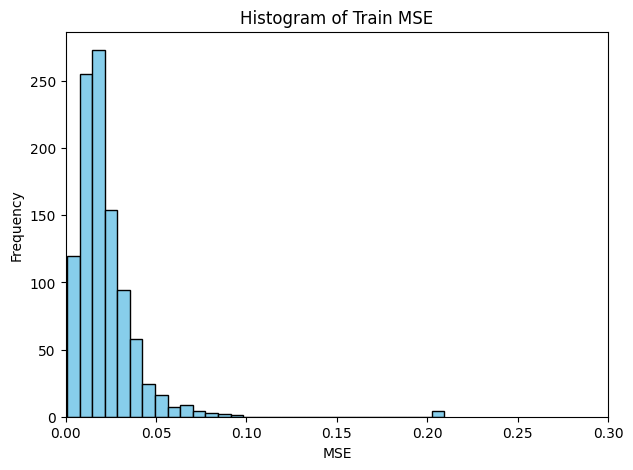

Mse: 0.021437738 Stdev: 0.017816871


In [77]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

dist_train = agent_ft.network.select('actor')(train_batch['observations'], train_batch['actor_goals'], params=agent_ft.network.updated_params_list[0])

mse_train = jnp.mean((dist_train.mode() - train_batch['actions']) ** 2, axis=-1)
mse_train_flat = jnp.asarray(mse_train).flatten()
plt.figure(figsize=(7,5))
plt.hist(np.asarray(mse_train_flat), bins=30, color='skyblue', edgecolor='black')
plt.xlim(0, 0.3)
plt.title('Histogram of Train MSE')
plt.xlabel('MSE')
plt.ylabel('Frequency')
plt.show()
print("Mse:", jnp.mean(mse_train), "Stdev:", jnp.std(mse_train))


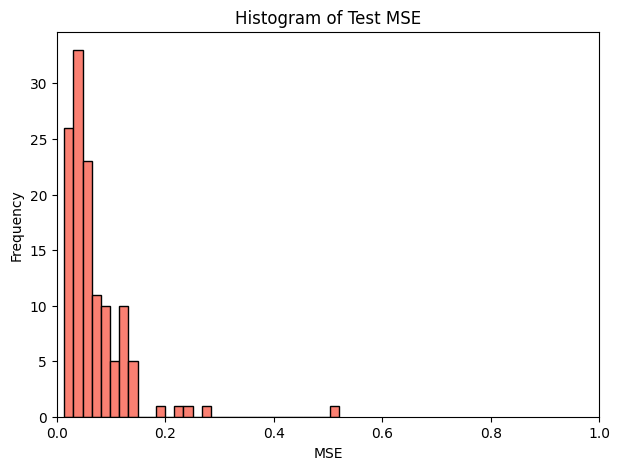

Mse: 0.067940466 Stdev: 0.060839072


In [80]:
dist_test = agent_ft.network.select('actor')(test_batch['observations'], test_batch['actor_goals'], params=agent_ft.network.updated_params_list[0])
import matplotlib.pyplot as plt
import numpy as np
mse = jnp.mean((dist_test.mode() - test_batch['actions']) ** 2, axis=-1)
mse_flat = jnp.asarray(mse).flatten()
plt.figure(figsize=(7,5))
plt.xlim(0, 1)
plt.hist(np.asarray(mse_flat), bins=30, color='salmon', edgecolor='black')
plt.title('Histogram of Test MSE')
plt.xlabel('MSE')
plt.ylabel('Frequency')
plt.show()
print("Mse:", jnp.mean(mse), "Stdev:", jnp.std(mse))

In [18]:
train_batch, _ = fetch_meta_batch(
    train_dataset,
    goals[0],
    agent,
    cfg.finetune,
    batch_filters_and_max_lens[0],
    exclude=test_batch_idx,
    fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
)

In [17]:
len(np.unique(test_batch_idx))

119

In [19]:
train_batch

{'actions': array([[-1.        , -0.9572842 , -0.62552476, ...,  0.94703823,
          0.9016789 , -0.96443355],
        [ 0.65905625, -0.41296664,  0.62407947, ...,  0.30016285,
         -0.7643781 ,  1.        ],
        [ 0.71118635, -0.3090624 , -1.        , ...,  0.7047484 ,
          0.39147133, -0.5189043 ],
        ...,
        [ 0.7793981 , -0.69945633,  0.71844655, ..., -0.83902895,
         -0.99986506,  0.763232  ],
        [ 0.5137615 , -0.92221653,  0.905917  , ...,  0.0491398 ,
         -0.85282713,  0.57351595],
        [ 1.        , -0.5066817 ,  0.14900523, ...,  0.23843656,
         -0.9475958 ,  0.6565453 ]], shape=(1024, 8), dtype=float32),
 'observations': array([[ 1.1180112e+01,  1.1826436e+01,  5.6779885e-01, ...,
         -3.5720888e-01, -7.0759547e-01,  4.5466796e-03],
        [ 1.1132301e+01,  1.1982944e+01,  6.3314599e-01, ...,
         -1.3179847e-02,  1.6362353e-01, -4.7216396e+00],
        [ 1.1072572e+01,  8.1129332e+00,  5.3095663e-01, ...,
         -2.

In [15]:
test_batch

{'actions': array([[-0.708906  , -0.6966641 , -0.30382714, ...,  0.4723053 ,
          0.5823576 , -0.99750066],
        [-0.43894187,  0.66024965, -0.8761094 , ...,  0.7728314 ,
          0.00861484, -0.4452018 ],
        [ 0.7098156 , -1.        , -0.74847114, ...,  1.        ,
          0.0791056 , -0.03694956],
        ...,
        [-0.7281997 , -0.9332555 , -0.8111417 , ...,  0.9214799 ,
          1.        , -0.5153093 ],
        [ 1.        , -0.07342064,  0.873541  , ..., -0.19250752,
         -1.        ,  0.7675186 ],
        [ 0.7043346 , -0.0133329 , -0.4132586 , ...,  0.56052494,
         -0.03009083,  0.46718276]], shape=(128, 8), dtype=float32),
 'observations': array([[ 8.19837093e+00,  1.61618633e+01,  6.39235675e-01, ...,
         -8.28612745e-02, -4.32188928e-01,  5.11941016e-01],
        [ 9.58829880e+00,  1.48928442e+01,  6.78406715e-01, ...,
         -3.33911252e+00, -2.21586847e+00,  9.45362002e-02],
        [ 1.06230431e+01,  9.38558388e+00,  6.97747886e-01, ...

NameError: name 'grad_cos_sims' is not defined

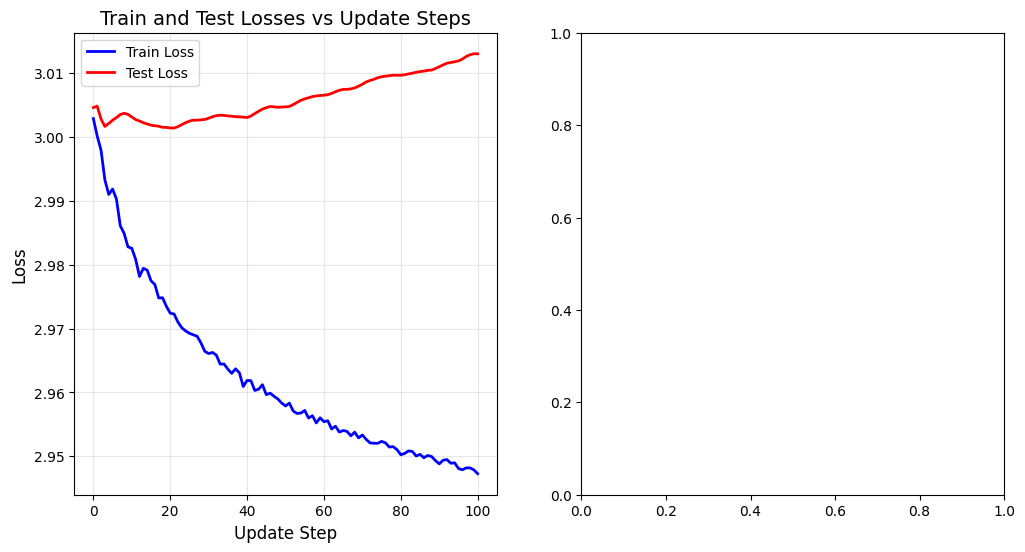

In [9]:
# Plot the losses and gradient cosine similarity
plt.figure(figsize=(12, 6))

# First subplot: train/test losses
plt.subplot(1, 2, 1)
plt.plot(update_steps, train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(update_steps, test_losses, 'r-', label='Test Loss', linewidth=2)
plt.xlabel('Update Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Train and Test Losses vs Update Steps', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Second subplot: gradient cosine similarity
plt.subplot(1, 2, 2)
plt.plot(update_steps, grad_cos_sims, 'g-', label='Grad Cos Sim', linewidth=2)
plt.xlabel('Update Step', fontsize=12)
plt.ylabel('Gradient Cosine Similarity', fontsize=12)
plt.title('Gradient Cosine Similarity vs Update Steps', fontsize=14)
plt.ylim(-1, 1)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nFinal Statistics:")
print(f"  Initial Test Loss: {initial_test_loss:.6f}")
print(f"  Final Train Loss: {train_losses[-1]:.6f}")
print(f"  Final Test Loss: {test_losses[-1]:.6f}")
print(f"  Test Loss Reduction: {((initial_test_loss - test_losses[-1]) / initial_test_loss * 100):.2f}%")